# 03_analysis.ipynb — Exploratory Data Analysis

**Input:** `../data/metadata.csv`, `../data/SC/SC{sid:02d}.npz`  
**Outputs:** figures in `../figures/`, exclusion list printed for records

Addresses the two open issues from Phase 0:
1. 38 % artifact rate — investigate per-subject distribution and stage concentration
2. Stage anomaly (N1 = 25.9 %, REM = 6.4 %) — identify outliers vs systematic causes

Standard EDA follows: representative hypnograms, group-average hypnogram, stage proportion chart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

SC_DIR  = Path('../data/SC')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

meta = pd.read_csv('../data/metadata.csv')
meta['artifact_pct'] = 100 * meta['n_artifact'] / meta['n_epochs']
STAGE_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = ['#6baed6', '#9ecae1', '#2171b5', '#08306b', '#fc8d59']
print(meta.describe().round(1))

       subject  n_epochs  n_artifact  Wake     N1     N2     N3   REM  \
count     76.0      76.0        76.0  76.0   76.0   76.0   76.0  76.0   
mean      39.2     141.6        53.8  23.6   36.6   41.6   30.8   9.0   
std       23.9      52.6        41.2  14.0   20.9   17.3   26.3   6.0   
min        0.0      49.0         3.0   5.0    5.0   12.0    0.0   1.0   
25%       18.8     108.0        18.8  14.0   19.0   29.5    9.8   5.8   
50%       39.0     135.0        48.0  20.0   32.5   40.0   23.0   8.0   
75%       59.2     177.2        73.8  30.0   49.8   53.0   50.2  11.0   
max       82.0     300.0       204.0  59.0  101.0  102.0  104.0  35.0   

       artifact_pct  
count          76.0  
mean           35.9  
std            21.0  
min             2.0  
25%            20.0  
50%            31.7  
75%            49.2  
max            85.6  


## 1. Artifact rate per subject

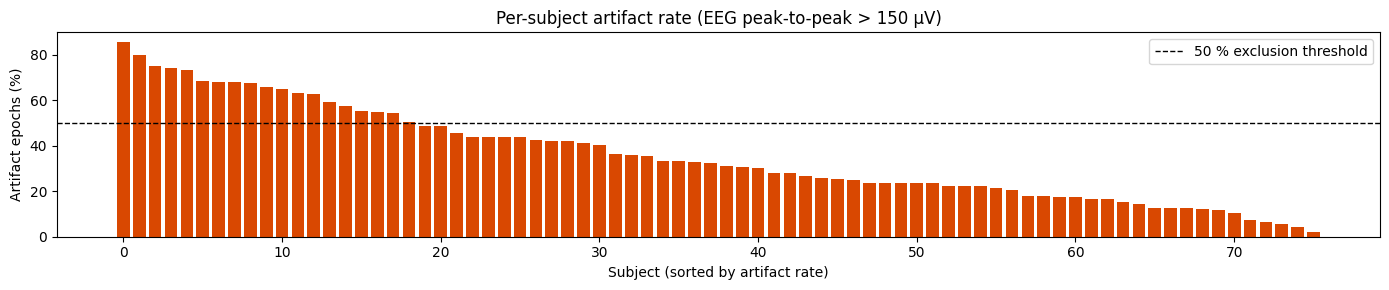


Artifact concentration by stage:
  Wake : 1095 /  1793  (61.0%)
  N1   :  648 /  2783  (23.3%)
  N2   :  804 /  3163  (25.4%)
  N3   : 1473 /  2339  (62.9%)
  REM  :   66 /   686  (9.6%)


In [2]:
fig, ax = plt.subplots(figsize=(14, 3))
srt = meta.sort_values('artifact_pct', ascending=False).reset_index(drop=True)
bars = ax.bar(range(len(srt)), srt['artifact_pct'], color='#d94801', width=0.8)
ax.axhline(50, color='black', lw=1, ls='--', label='50 % exclusion threshold')
ax.set_xlabel('Subject (sorted by artifact rate)')
ax.set_ylabel('Artifact epochs (%)')
ax.set_title('Per-subject artifact rate (EEG peak-to-peak > 150 µV)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'artifact_rate.png', dpi=150)
plt.show()

# Investigate stage concentration of artifacts
stage_artifact_counts = {s: 0 for s in STAGE_NAMES}
for sid in meta['subject']:
    arr   = np.load(SC_DIR / f'SC{sid:02d}.npz')
    amask = arr['artifact_mask']
    labs  = arr['labels']
    for si, sn in enumerate(STAGE_NAMES):
        stage_artifact_counts[sn] += int(np.sum(amask & (labs == si)))

stage_total = {sn: int(meta[sn].sum()) for sn in STAGE_NAMES}
print('\nArtifact concentration by stage:')
for sn in STAGE_NAMES:
    pct = 100 * stage_artifact_counts[sn] / (stage_total[sn] + 1)
    print(f'  {sn:5s}: {stage_artifact_counts[sn]:4d} / {stage_total[sn]:5d}  ({pct:.1f}%)')

## 2. Stage distribution per subject

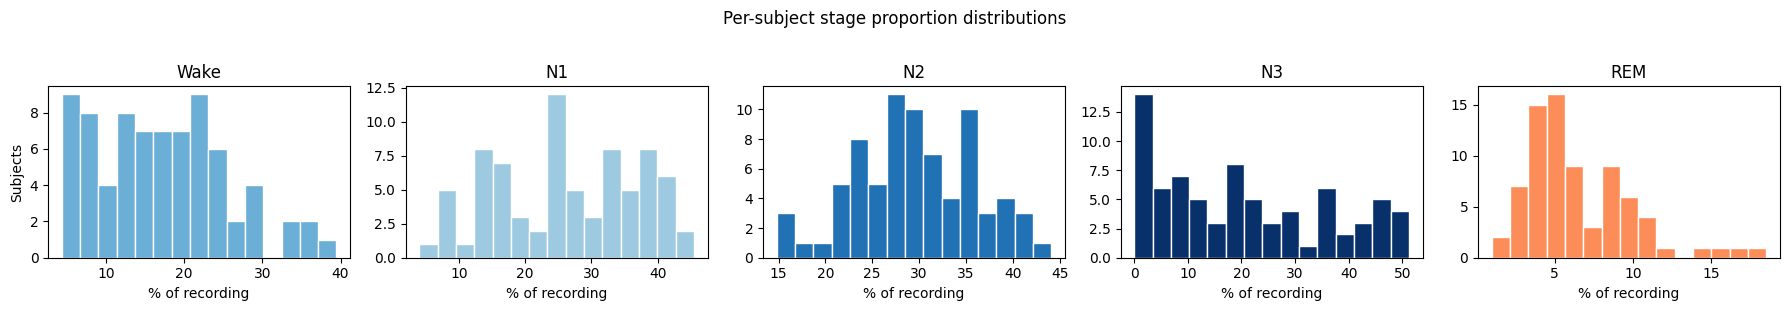

High N1 (>40%): subjects [51, 54, 58, 64, 73, 74]
Zero REM:       subjects []
Zero N3:        subjects [32, 33, 34, 57, 64, 72, 73, 74, 75]


In [3]:
# Compute per-subject stage proportions
for sn in STAGE_NAMES:
    meta[f'{sn}_pct'] = 100 * meta[sn] / meta['n_epochs']

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)
for ax, sn, col in zip(axes, STAGE_NAMES, STAGE_COLORS):
    ax.hist(meta[f'{sn}_pct'], bins=15, color=col, edgecolor='white')
    ax.set_title(sn)
    ax.set_xlabel('% of recording')
axes[0].set_ylabel('Subjects')
plt.suptitle('Per-subject stage proportion distributions', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'stage_distributions.png', dpi=150)
plt.show()

# Flag high-N1 outliers (N1 > 40%) and zero-REM subjects
high_n1    = meta[meta['N1_pct'] > 40]['subject'].tolist()
zero_rem   = meta[meta['REM'] == 0]['subject'].tolist()
zero_n3    = meta[meta['N3']  == 0]['subject'].tolist()
print(f'High N1 (>40%): subjects {high_n1}')
print(f'Zero REM:       subjects {zero_rem}')
print(f'Zero N3:        subjects {zero_n3}')

## 3. Exclusion criteria and valid subject list

In [4]:
# Exclusion: artifact rate >= 50% OR fewer than 60 clean epochs (~30 min)
meta['n_clean']     = meta['n_epochs'] - meta['n_artifact']
excluded_artifact   = meta[meta['artifact_pct'] >= 50]['subject'].tolist()
excluded_short      = meta[(meta['artifact_pct'] < 50) &
                            (meta['n_clean'] < 60)]['subject'].tolist()
valid_subs          = meta[
    (meta['artifact_pct'] < 50) & (meta['n_clean'] >= 60)
]['subject'].tolist()

print(f'Excluded (artifact >= 50%):  {excluded_artifact}')
print(f'Excluded (< 60 clean epochs): {excluded_short}')
print(f'Valid subjects: {len(valid_subs)}')

# Flag for cycle analysis: fewer than 3 complete cycles expected
# (rough proxy: total clean sleep < 180 min)
meta_valid = meta[meta['subject'].isin(valid_subs)].copy()
short_rec  = meta_valid[
    (meta_valid['n_clean'] * 0.5 / 60) < 180  # < 3 h clean sleep
]['subject'].tolist()
print(f'Flagged for sensitivity analysis (< 3 h clean sleep): {short_rec}')

Excluded (artifact >= 50%):  [0, 3, 5, 6, 7, 8, 13, 14, 16, 17, 22, 27, 29, 43, 47, 49, 61, 66, 82]
Excluded (< 60 clean epochs): [10, 20, 32, 34, 40, 72, 75]
Valid subjects: 50
Flagged for sensitivity analysis (< 3 h clean sleep): [1, 2, 4, 9, 11, 12, 15, 18, 19, 21, 23, 24, 25, 26, 28, 30, 31, 33, 35, 37, 38, 41, 42, 44, 45, 46, 48, 50, 51, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 67, 70, 71, 73, 74, 76, 77, 80, 81]


## 4. Summary statistics

In [5]:
print('=== Valid-subject summary ===')
print(meta_valid[['n_epochs', 'n_clean', 'artifact_pct'] +
                  [f'{s}_pct' for s in STAGE_NAMES]].describe().round(2))

=== Valid-subject summary ===
       n_epochs  n_clean  artifact_pct  Wake_pct  N1_pct  N2_pct  N3_pct  \
count     50.00    50.00         50.00     50.00   50.00   50.00   50.00   
mean     145.60   106.48         25.93     17.27   27.67   30.29   18.44   
std       45.41    34.72         12.22      7.64   10.89    6.98   14.79   
min       69.00    65.00          1.97      4.84    4.03   14.81    0.00   
25%      110.50    77.25         16.82     11.81   20.54   26.85    5.89   
50%      135.00    98.50         25.10     16.67   27.37   29.67   17.08   
75%      179.50   135.25         35.09     22.47   36.81   35.83   25.56   
max      250.00   191.00         48.75     33.54   45.45   44.12   51.23   

       REM_pct  
count    50.00  
mean      6.34  
std       2.94  
min       0.98  
25%       4.24  
50%       5.66  
75%       8.69  
max      15.09  


## 5. Representative hypnograms

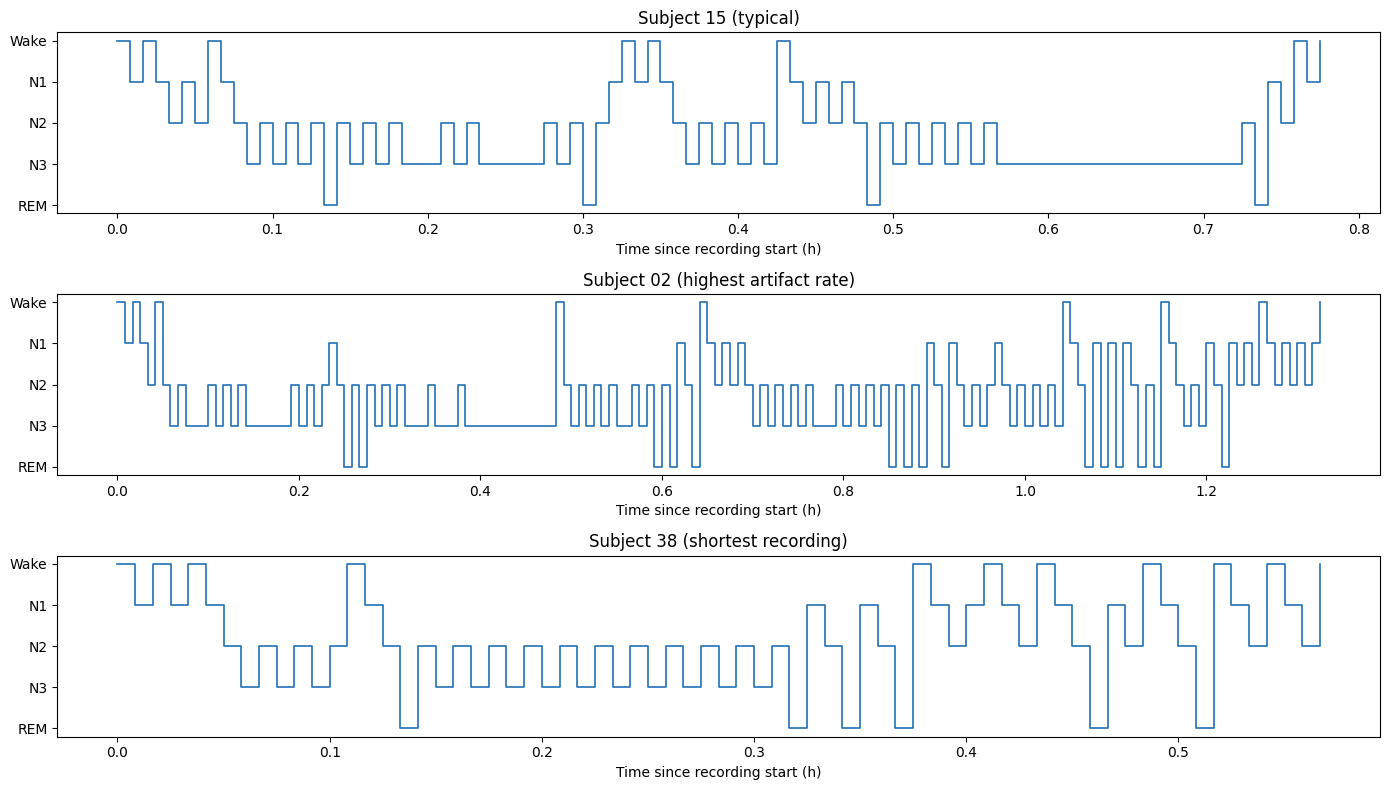

In [8]:
def plot_hypnogram(ax, labels, sid, title_suffix=''):
    t = np.arange(len(labels)) * 30 / 3600   # hours
    ax.step(t, labels, where='post', lw=1.2, color='#2171b5')
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_yticklabels(['Wake', 'N1', 'N2', 'N3', 'REM'])
    ax.set_xlabel('Time since recording start (h)')
    ax.set_title(f'Subject {int(sid):02d} {title_suffix}')
    ax.invert_yaxis()

# Pick: typical (median N2%), fragmented (high artifact), short recording
typical    = meta_valid.iloc[(meta_valid['N2_pct'] - meta_valid['N2_pct'].median()).abs().argsort()[:1]]['subject'].values[0]
fragmented = meta_valid.sort_values('artifact_pct', ascending=False).iloc[0]['subject']
short_sub  = meta_valid.sort_values('n_epochs').iloc[0]['subject']

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
for ax, sid, tag in zip(axes,
                        [typical, fragmented, short_sub],
                        ['(typical)', '(highest artifact rate)', '(shortest recording)']):
    labels = np.load(SC_DIR / f'SC{int(sid):02d}.npz')['labels']
    plot_hypnogram(ax, labels, sid, tag)
plt.tight_layout()
plt.savefig(FIG_DIR / 'representative_hypnograms.png', dpi=150)
plt.show()

## 6. Group-average hypnogram (modal stage per time bin) — Paper Figure 1

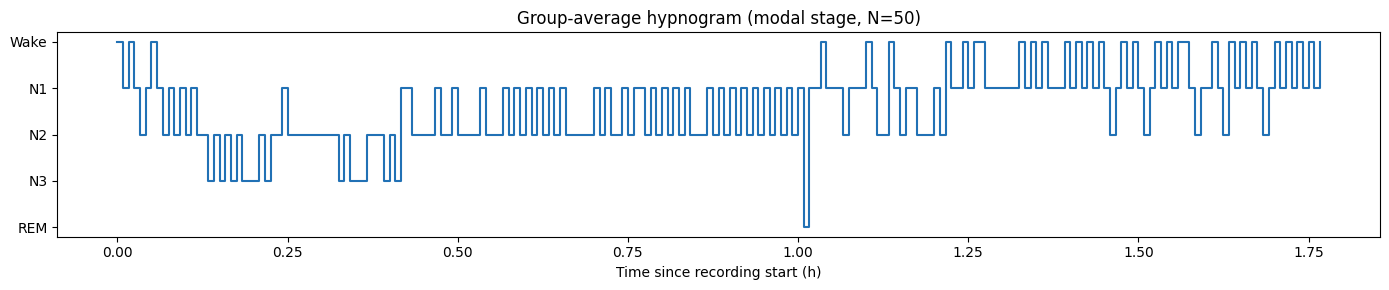

In [9]:
from scipy import stats as sp_stats

MAX_EPOCHS = 300  # ~2.5 h, covers most recordings
all_labels = np.full((len(valid_subs), MAX_EPOCHS), np.nan)

for row_i, sid in enumerate(valid_subs):
    labs = np.load(SC_DIR / f'SC{sid:02d}.npz')['labels']
    n    = min(len(labs), MAX_EPOCHS)
    all_labels[row_i, :n] = labs[:n]

modal = np.full(MAX_EPOCHS, np.nan)
for j in range(MAX_EPOCHS):
    col = all_labels[:, j]
    col = col[~np.isnan(col)]
    if len(col) >= 5:   # at least 5 subjects must have data at this time point
        modal[j] = sp_stats.mode(col, keepdims=True).mode[0]

valid_t = ~np.isnan(modal)
t = np.arange(MAX_EPOCHS)[valid_t] * 30 / 3600

fig, ax = plt.subplots(figsize=(14, 3))
ax.step(t, modal[valid_t], where='post', lw=1.5, color='#2171b5')
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['Wake', 'N1', 'N2', 'N3', 'REM'])
ax.invert_yaxis()
ax.set_xlabel('Time since recording start (h)')
ax.set_title(f'Group-average hypnogram (modal stage, N={len(valid_subs)})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'group_avg_hypnogram.png', dpi=300)
plt.show()

## 7. Stage proportion bar chart — Paper Figure 2

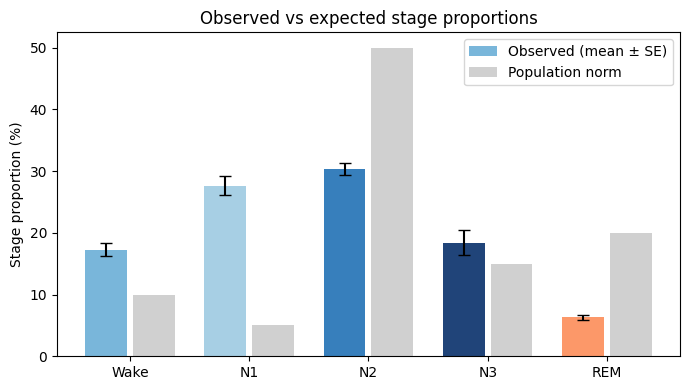

In [10]:
means = [meta_valid[f'{s}_pct'].mean() for s in STAGE_NAMES]
sems  = [meta_valid[f'{s}_pct'].sem()  for s in STAGE_NAMES]

# Population norms for comparison
norms = {'Wake': 10, 'N1': 5, 'N2': 50, 'N3': 15, 'REM': 20}

x = np.arange(len(STAGE_NAMES))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, means, 0.35, yerr=sems, capsize=4,
       color=STAGE_COLORS, label='Observed (mean ± SE)', alpha=0.9)
ax.bar(x + 0.2, [norms[s] for s in STAGE_NAMES], 0.35,
       color='#bdbdbd', label='Population norm', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(STAGE_NAMES)
ax.set_ylabel('Stage proportion (%)')
ax.set_title('Observed vs expected stage proportions')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'stage_proportions.png', dpi=300)
plt.show()